# EGFP-DsRed 

Notebook implementing reconstruction of raw measuremenets of EGFP-DsRed sample, acquired using Hadamard motifs. 

The raw data and motif measurements must first be preprocessed by running *main_preprocess_EGFP-DsRed.py*

Two reconstruction methods are implemented:
- Direct Reconstruction, using the pseudo inverse: $\bm F_\lambda = \bm H^\dagger \bm M_\lambda$
- Tikhonov Regularisation  + Unet: $\bm F_\lambda = \mathcal G_\theta ( \bm \Sigma \bm H^\top ( \bm {H\Sigma H^\top} + \bm \Gamma)^{-1}\bm M_\lambda )$

Where $\mathcal G_\theta$ is a pre-trained neural network with parameters $\theta$ acting in the spatial domain. 

In [2]:
import collections
collections.Callable = collections.abc.Callable
fig_folder = './figure/'
from pathlib import Path
from spyrit.misc.disp import add_colorbar, noaxis
import matplotlib.pyplot as plt
from spyrit.misc.walsh_hadamard import walsh_matrix
import numpy as np
import torch

from spyrit.core.meas import LinearSplit
from spyrit.core.noise import Poisson
from spyrit.core.prep import Rerange, UnsplitRescale
from spyrit.core.nnet import Unet, Identity
from spyrit.core.train import load_net

from spyrit.core.recon import TikhoNet
from spyrit.core.nnet import Unet, Identity
from typing import OrderedDict

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
save_rec = True
save_fig = True

M = 128
N = 512

# Data Paths
data_folder = './data/2023_03_13_2023_03_14_eGFP_DsRed_3D'  # main directory
mat_folder = '/Reconstruction/Mat_rc/'  # prepped matrices
data_subfolder = 'data_2023_03_14/'  # raw data
prep_folder = '/Preprocess/'  # prepped raw data


channel = 10, 55, 100       # to be plotted
Nl, Nh, Nc = 512, 128, 128  # shape of preprocessed data

# experimental parameters
nbin = 20*4
mudark = 105.0
sigdark = 5.0
gain = 2.6

# to locate positive / negative measures
even_index = range(0, 2 *M, 2)
odd_index = range(1, 2 *M, 2)


## Load Hadamard matrices

First load in the prepped Hadamard motifs and compare them to the target patterns

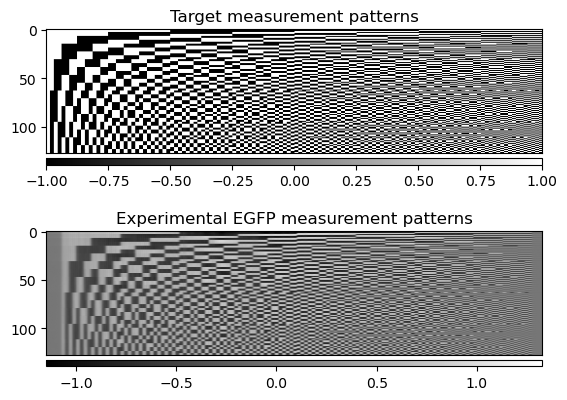

In [11]:

H_exp = np.load(Path(data_folder + mat_folder) / f'motifs_Hadamard_{M}_{N}.npy')
H_exp /= H_exp[0,16:500].mean()


H_tar = walsh_matrix(N)
H_tar = H_tar[:M]

# plot
f, axs = plt.subplots(2, 1)
axs[0].set_title('Target measurement patterns')
im = axs[0].imshow(H_tar, cmap='gray') 
add_colorbar(im, 'bottom')
axs[0].get_xaxis().set_visible(False)

axs[1].set_title('Experimental EGFP measurement patterns')
im = axs[1].imshow(H_exp, cmap='gray') 
add_colorbar(im, 'bottom')
axs[1].get_xaxis().set_visible(False)

H = torch.from_numpy(H_exp)


## TIKHONET

Reconstruction using Tikhonov Regularisation and Unet Denoiser

The covariance matrix can be downloaded [here] (https://pilot-warehouse.creatis.insa-lyon.fr/#collection/63caa9497bef31845d991351/folder/6464d58285f48d3da0718935)

The model can be downloaded [here](https://pilot-warehouse.creatis.insa-lyon.fr/#collection/63caa9497bef31845d991351/folder/6464d5f585f48d3da071893c)

In [7]:
import torch.nn as nn

div = 1.5
alpha = 50

# where to save reconstructions
recon = f'tikhonet{alpha}_div{div}_exp'
save_folder = f'/Reconstruction/hypercube/tikhonet{alpha}_div{div}/'

# (downloaded) covariance prior in the image domain
stat_folder = './stat/'
cov_file   = f'Cov_1_{N}x{N}.npy'
sigma = np.load(Path(stat_folder) / cov_file)

# (downloaded) pretrained net
net_prefix = f'tikho-net_unet_imagenet_ph_{alpha}'
net_suffix = 'N_512_M_128_epo_20_lr_0.001_sss_10_sdr_0.5_bs_20_reg_1e-07'
title = './model/' + net_prefix + '_exp_' + net_suffix + '.pth'


# set up
noise = Poisson(alpha)
linop = LinearSplit(H, meas_shape=(1, N),  noise_model=noise, device=device)
prep   = Identity() # done by hand in reconstruction loop, using normalisation valued re-calculated for each batch
rerange = Rerange((0, 1), (-1, 1))



denoiser = OrderedDict({"rerange": rerange, "denoi": Unet(), "rerange_inv": rerange.inverse()})
denoiser = nn.Sequential(denoiser)

load_net(title, denoiser, device, False)


recnet = TikhoNet(linop, prep.to(device), torch.from_numpy(sigma/div).to(device), denoiser, device=device)  
recnet.eval()   # Mandantory when batchNorm is used


Model Loaded: ./model/tikho-net_unet_imagenet_ph_50_exp_N_512_M_128_epo_20_lr_0.001_sss_10_sdr_0.5_bs_20_reg_1e-07.pth


TikhoNet(
  (acqu_modules): Sequential(
    (acqu): LinearSplit(
      (noise_model): Poisson()
    )
  )
  (recon_modules): Sequential(
    (prep): Identity()
    (tikho): Tikhonov(
      (meas_op): LinearSplit(
        (noise_model): Poisson()
      )
    )
    (denoi): Sequential(
      (rerange): Rerange((0, 1) -> (-1, 1))
      (denoi): Unet(
        (conv_encode1): Sequential(
          (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU()
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): ReLU()
          (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv_maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (conv_encode2): Sequential(
          (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=

In [8]:

# Reconstruct all channels per batch
n_batch = 8 # a power of two
n_wav = Nc // n_batch


T_list = range(1,27)    # slice indices
for t in T_list:
    if t<6:
        date = '2023_03_13'
        Run = f'RUN{t+1:04}'
    else:
        date = '2023_03_14'
        Run = f'RUN{t-5:04}'

    # Load prep data
    filename = f'T{t}_{Run}_{date}_Had_{Nl}_{Nh}_{Nc}_pos.npy'
    prep_pos = np.load(Path(data_folder+prep_folder) / filename)
    
    filename = f'T{t}_{Run}_{date}_Had_{Nl}_{Nh}_{Nc}_neg.npy'
    prep_neg =  np.load(Path(data_folder+prep_folder) / filename)
    
    # spectral dimension comes first
    prep_pos = np.moveaxis(prep_pos, -1, 0)
    prep_neg = np.moveaxis(prep_neg, -1, 0)
    
    # param #2
    background  = (2**15-1)*nbin
    
    prep_pos = prep_pos - background
    prep_neg = prep_neg - background
    
    nc, nl, nh = prep_neg.shape
    y = np.zeros((nc, nl, 2*nh))
    y[:,:,::2]  = prep_pos 
    y[:,:,1::2] = prep_neg 
    y = torch.from_numpy(y)
    
    print(f'Loaded: {filename[:-8]}')
    print(f'Pos data: range={prep_pos.max() - prep_pos.min()} counts; mean={prep_pos.mean()} counts')  
    
    y = y.to(device)
    y = y.view(-1,1,N,2*M) 

    rec = np.zeros((Nc, N, N))
    beta = np.zeros(Nc)
    

    # reconstruct this slice batch by batch
    with torch.no_grad():
        for b in range(n_batch):       
            ind = range(b*n_wav, (b+1)*n_wav)  

            # extract batch and unsplit
            m = y[ind,:,:].to(device, torch.float32)
            m_unsplit = m[..., even_index] - m[..., odd_index]
            z =  m[..., even_index] + m[..., odd_index]

            # calcuate batch mean, normalisation value and variance - using experimental parameters
            mu = torch.mean(z, dim=-1, keepdim=True)
            alpha =  ((2 / N) * (mu - 2 * mudark) / gain).to(device)
            alpha = torch.amax(alpha, -2, keepdim=True)
            norm = alpha*gain

            sigma =  (gain * (z - 2 * nbin * mudark)+ 2 * nbin * sigdark**2)*4
            cov_meas = sigma / norm**2
            cov_meas = torch.diag_embed(cov_meas)

            print(f'reconstructing batch {ind.start}--{ind.stop}')

            m = m_unsplit/norm # unsplit and rescale

            x_hat = recnet.tikho(m,cov_meas) # tikhonov reconstruction
            x_hat = x_hat.squeeze()
            x_hat = x_hat.view(x_hat.shape[0], 1, N, N)
            
            x_tilde = denoiser(x_hat) # unet denoise
            rec_gpu = x_tilde*norm  # denormalise
         
            rec[ind,:,:] = rec_gpu.cpu().detach().numpy().squeeze()
            beta[ind] = norm.cpu().detach().numpy().squeeze()
       
        rec = np.moveaxis(rec, 0, -1) # spectral channel is now the last axis
        
        if save_rec:
            Path(data_folder+save_folder).mkdir(parents=True, exist_ok=True)
            
            save_filename = filename[:-20].replace('Had', 'rec_' + recon) + f'_{N}x{N}x{nc}.npy'
            np.save(Path(data_folder+save_folder) / save_filename, rec)
            
            save_filename = filename[:-20].replace('Had', 'beta_' + recon) + f'_{N}x{N}x{nc}.npy'
            np.save(Path(data_folder+save_folder) / save_filename, beta)
       
    
del recnet

Loaded: T1_RUN0002_2023_03_13_Had_512_128_128
Pos data: range=17193.0 counts; mean=9087.304466605186 counts
reconstructing batch 0--16
reconstructing batch 16--32
reconstructing batch 32--48
reconstructing batch 48--64
reconstructing batch 64--80
reconstructing batch 80--96
reconstructing batch 96--112
reconstructing batch 112--128
Loaded: T2_RUN0003_2023_03_13_Had_512_128_128
Pos data: range=17322.0 counts; mean=9324.982338309288 counts
reconstructing batch 0--16
reconstructing batch 16--32
reconstructing batch 32--48
reconstructing batch 48--64
reconstructing batch 64--80
reconstructing batch 80--96
reconstructing batch 96--112
reconstructing batch 112--128
Loaded: T3_RUN0004_2023_03_13_Had_512_128_128
Pos data: range=16111.0 counts; mean=9291.939488649368 counts
reconstructing batch 0--16
reconstructing batch 16--32
reconstructing batch 32--48
reconstructing batch 48--64
reconstructing batch 64--80
reconstructing batch 80--96
reconstructing batch 96--112
reconstructing batch 112--12

## PSEUDOINVERSE

Reconstruction using the pseudoinverse only 

In [6]:
from spyrit.core.recon import PinvNet

#where to save reconstructions
recon = 'pinv_exp'
save_folder = '/Reconstruction/hypercube/pinv/'

# create reconstruction network
recnet = PinvNet(linop, store_H_pinv=True, device=device)

# Reconstruct all channels per batch
n_batch = 8 # a power of two
n_wav = Nc // n_batch

for t in T_list:

    if t<6:
        date = '2023_03_13'
        Run = f'RUN{t+1:04}'
    else:
        date = '2023_03_14'
        Run = f'RUN{t-5:04}'

    # Load prep data
    filename = f'T{t}_{Run}_{date}_Had_{Nl}_{Nh}_{Nc}_pos.npy'
    prep_pos = np.load(Path(data_folder+prep_folder) / filename)
    
    filename = f'T{t}_{Run}_{date}_Had_{Nl}_{Nh}_{Nc}_neg.npy'
    prep_neg =  np.load(Path(data_folder+prep_folder) / filename)
    
    # spectral dimension comes first
    prep_pos = np.moveaxis(prep_pos, -1, 0)
    prep_neg = np.moveaxis(prep_neg, -1, 0)
    
    # param #2
    background  = (2**15-1)*nbin
    
    prep_pos = prep_pos - background
    prep_neg = prep_neg - background
    
    nc, nl, nh = prep_neg.shape
    y = np.zeros((nc, nl, 2*nh))
    y[:,:,::2]  = prep_pos 
    y[:,:,1::2] = prep_neg 
    y = torch.from_numpy(y)
    
    print(f'Loaded: {filename[:-8]}')
    print(f'Pos data: range={prep_pos.max() - prep_pos.min()} counts; mean={prep_pos.mean()} counts')  
    
    y = y.to(device)
    y = y.view(-1,1,N,2*M) 
    
    rec = np.zeros((Nc, N, N))
    beta = np.zeros(Nc)
    
    with torch.no_grad():
        for b in range(n_batch):       

            ind = range(b*n_wav, (b+1)*n_wav)  
                      
            m = y[ind,:,:].to(device, torch.float32)

            y_unsplit = m[..., even_index] - m[..., odd_index]
            z =  m[..., even_index] + m[..., odd_index]
            mu = torch.mean(z, dim=-1, keepdim=True)
            alpha =  ((2 / N) * (mu - 2 * mudark) / gain).to(device)
            alpha = torch.amax(alpha, -2, keepdim=True)
            norm = alpha*gain

            print(f'reconstructing batch {ind.start}--{ind.stop}')
            m = y_unsplit/norm

            x_hat = recnet.pinv(m) # pseudoinverse reconstruction
            x_hat = x_hat.squeeze()
            x_hat = x_hat.view(x_hat.shape[0], 1, N, N)
            
            rec_gpu = x_hat*norm # denormalise
         
            rec[ind,:,:] = rec_gpu.cpu().detach().numpy().squeeze()
            beta[ind] = norm.cpu().detach().numpy().squeeze()
        rec = np.moveaxis(rec, 0, -1) # spectral channel is now the last axis
        
        if save_rec: 
            Path(data_folder+save_folder).mkdir(parents=True, exist_ok=True)
            
            save_filename = filename[:-20].replace('Had', 'rec_' + recon) + f'_{N}x{N}x{nc}.npy'
            np.save(Path(data_folder+save_folder) / save_filename, rec)
            
            save_filename = filename[:-20].replace('Had', 'beta' + recon) + f'_{N}x{N}x{nc}.npy'
            np.save(Path(data_folder+save_folder) / save_filename, beta)
            
            
        if save_fig:
            save_filename = filename[:-20].replace('Had','rec_' + recon) + f'_{N}x{N}x{nc}.png'
            plt.savefig(Path(data_folder+save_folder)/save_filename, bbox_inches='tight', dpi=600)
    
del recnet

Loaded: T1_RUN0002_2023_03_13_Had_512_128_128
Pos data: range=17193.0 counts; mean=9087.304466605186 counts
reconstructing batch 0--16
reconstructing batch 16--32
reconstructing batch 32--48
reconstructing batch 48--64
reconstructing batch 64--80
reconstructing batch 80--96
reconstructing batch 96--112
reconstructing batch 112--128
Loaded: T2_RUN0003_2023_03_13_Had_512_128_128
Pos data: range=17322.0 counts; mean=9324.982338309288 counts
reconstructing batch 0--16
reconstructing batch 16--32
reconstructing batch 32--48
reconstructing batch 48--64
reconstructing batch 64--80
reconstructing batch 80--96
reconstructing batch 96--112
reconstructing batch 112--128
Loaded: T3_RUN0004_2023_03_13_Had_512_128_128
Pos data: range=16111.0 counts; mean=9291.939488649368 counts
reconstructing batch 0--16
reconstructing batch 16--32
reconstructing batch 32--48
reconstructing batch 48--64
reconstructing batch 64--80
reconstructing batch 80--96
reconstructing batch 96--112
reconstructing batch 112--12

<Figure size 640x480 with 0 Axes>